In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("26-customer_data.csv")
df.head()

,Annual_Income,Spending_Score
0,-5.772478,-4.818216
1,6.768246,-5.424570
2,5.796159,-6.239967
3,7.096022,-5.272612
4,-5.725561,-9.316889


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Annual_Income   1499 non-null   float64
 1   Spending_Score  1499 non-null   float64
dtypes: float64(2)
memory usage: 23.6 KB


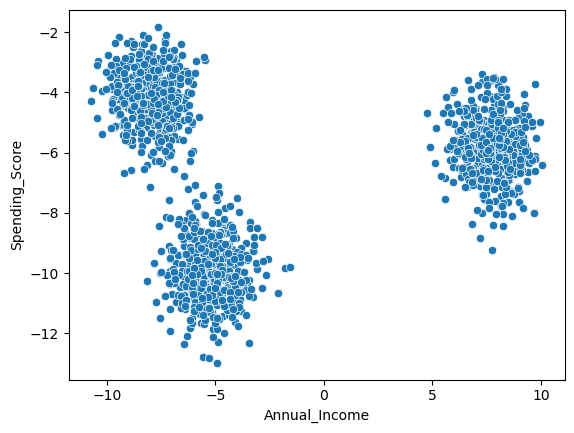

In [4]:
sns.scatterplot(data = df, x = "Annual_Income", y = "Spending_Score")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(df, test_size=0.2, random_state=15)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (1199, 2)
X_test: (300, 2)


In [6]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
from sklearn.cluster import KMeans

In [9]:
# elbow method
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [10]:
wcss

[196.92068784710153,
 68.44836482219307,
 11.697030239519934,
 9.903094841612722,
 7.808043380685502,
 6.0893525097330405,
 5.521267379883363,
 4.9896895643047445,
 4.599030364727377,
 4.085915889407186]

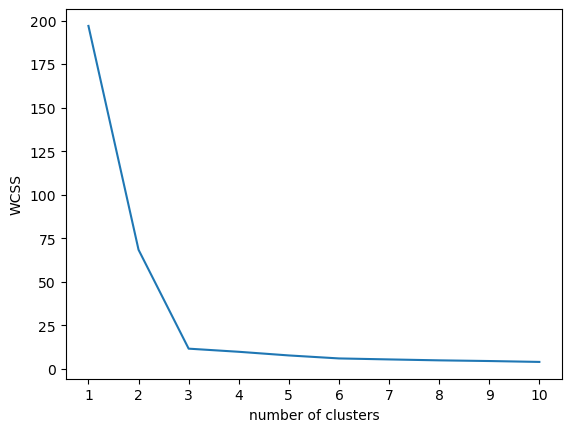

In [12]:
plt.plot(range(1,11), wcss)
plt.xticks(range(1,11))
plt.xlabel("number of clusters")
plt.ylabel("WCSS")
plt.show()

In [13]:
kmeans = KMeans(n_clusters=3)

In [14]:
kmeans.fit(X_train_scaled)

KMeans(n_clusters=3)

In [15]:
y_pred = kmeans.predict(X_test_scaled)

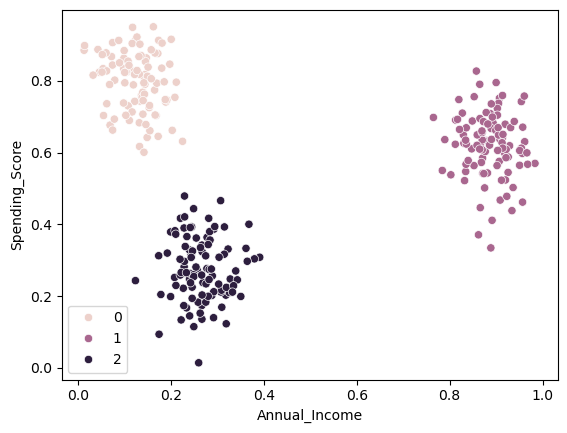

In [18]:
sns.scatterplot(data = pd.DataFrame(X_test_scaled, columns=X_test.columns), x = "Annual_Income", y = "Spending_Score", hue = y_pred)
plt.show()

In [23]:
!pip install kneed

Defaulting to user installation because normal site-packages is not writeable


In [24]:
from kneed import KneeLocator

In [26]:
kl = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")

In [27]:
kl.elbow

np.int64(3)

In [28]:
# silhoutte score
from sklearn.metrics import silhouette_score

In [32]:
silhoutte_scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    silhoutte_scores.append(score)

In [33]:
silhoutte_scores

[np.float64(0.6538372460771634),
 np.float64(0.7856941696336582),
 np.float64(0.6447386165583312),
 np.float64(0.5107287081029407),
 np.float64(0.6000337863899853),
 np.float64(0.38174529308268784),
 np.float64(0.35127853462933983),
 np.float64(0.3607568054827823),
 np.float64(0.3412404471541983)]

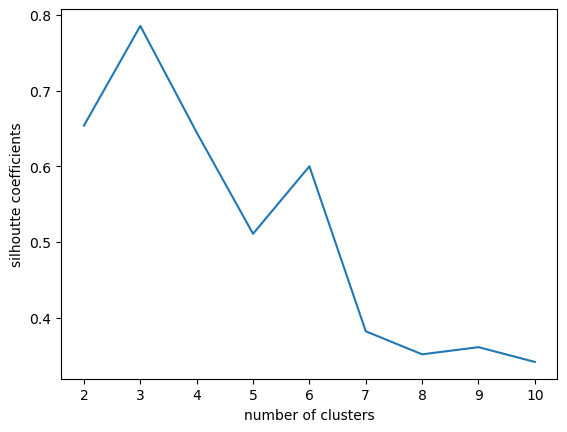

In [34]:
plt.plot(range(2,11), silhoutte_scores)
plt.xticks(range(2,11))
plt.xlabel("number of clusters")
plt.ylabel("silhoutte coefficients")
plt.show()